# Business Understanding

## Project Domain

## Problem Statements

## Goals

## Solution Statements

# Data Understanding

## Import data dari kaggle

In [1]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"alfatferdianwalid","key":"f5024dc13e3d2dacd3855f8029c300fc"}'}

In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!ls ~/.kaggle

kaggle.json


In [3]:
!kaggle datasets download -d mrsimple07/injury-prediction-dataset

Dataset URL: https://www.kaggle.com/datasets/mrsimple07/injury-prediction-dataset
License(s): apache-2.0


In [4]:
!mkdir injury-prediction-dataset
!unzip injury-prediction-dataset.zip -d injury-prediction-dataset
!ls injury-prediction-dataset

Archive:  injury-prediction-dataset.zip
  inflating: injury-prediction-dataset/injury_data.csv  
injury_data.csv


## Import Library yang dibutuhkan

In [5]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from matplotlib import pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder

import tensorflow as tf
from tensorflow.keras.layers import Dense, Activation
from tensorflow.keras import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import plot_model
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import r2_score

## Exploratory Data Analysis

In [10]:
data = pd.read_csv('/content/injury-prediction-dataset/injury_data.csv')
data.head()

,Player_Age,Player_Weight,Player_Height,Previous_Injuries,Training_Intensity,Recovery_Time,Likelihood_of_Injury
0,24,66.251933,175.732429,1,0.457929,5,0
1,37,70.996271,174.581650,0,0.226522,6,1
2,32,80.093781,186.329618,0,0.613970,2,1
3,28,87.473271,175.504240,1,0.252858,4,1
4,25,84.659220,190.175012,0,0.577632,1,1


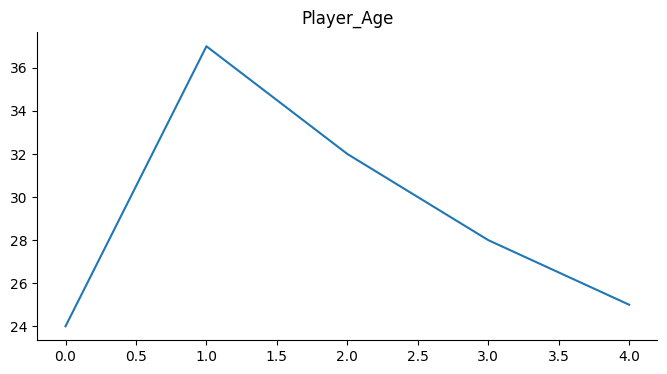

In [11]:
from matplotlib import pyplot as plt
_df_12['Player_Age'].plot(kind='line', figsize=(8, 4), title='Player_Age')
plt.gca().spines[['top', 'right']].set_visible(False)

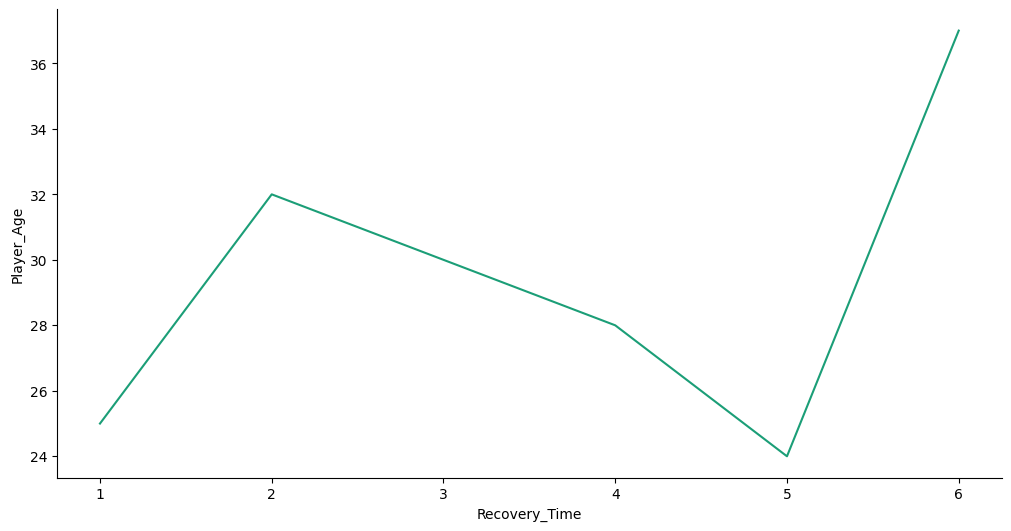

In [12]:
from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['Recovery_Time']
  ys = series['Player_Age']

  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_8.sort_values('Recovery_Time', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('Recovery_Time')
_ = plt.ylabel('Player_Age')

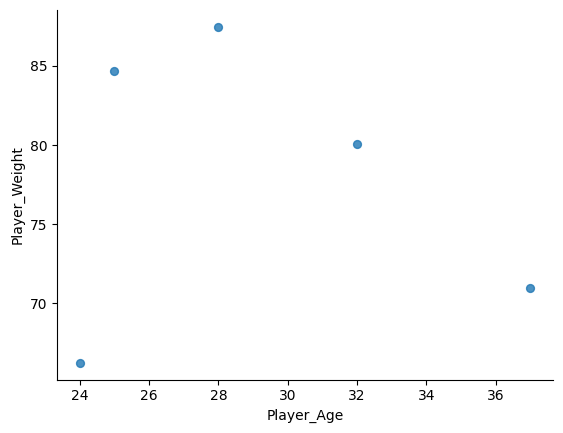

In [13]:
from matplotlib import pyplot as plt
_df_4.plot(kind='scatter', x='Player_Age', y='Player_Weight', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

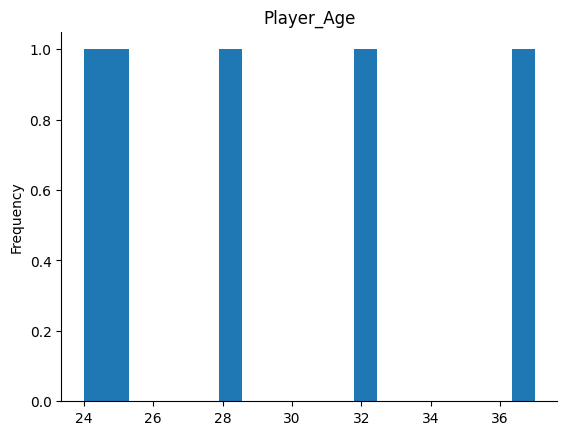

In [14]:
from matplotlib import pyplot as plt
_df_0['Player_Age'].plot(kind='hist', bins=20, title='Player_Age')
plt.gca().spines[['top', 'right',]].set_visible(False)

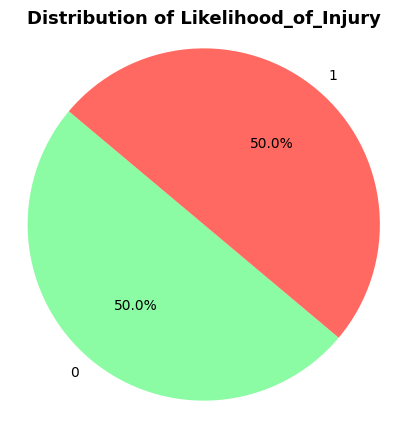

In [19]:
# Count 'Likelihood_of_Injury' | Contagem 'Likelihood_of_Injury'
li_count = data['Likelihood_of_Injury'].value_counts()

# Plot pie chart | Plotar o gráfico de pizza
plt.figure(figsize=(5, 5))
plt.pie(li_count, labels=li_count.index, autopct='%1.1f%%', startangle=140, colors=['#8CFCA4', '#FF6961'])
plt.title('Distribution of Likelihood_of_Injury', weight='bold', size=13)
plt.axis('equal')
plt.show()

# Data Preparation

In [21]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Player_Age            1000 non-null   int64  
 1   Player_Weight         1000 non-null   float64
 2   Player_Height         1000 non-null   float64
 3   Previous_Injuries     1000 non-null   int64  
 4   Training_Intensity    1000 non-null   float64
 5   Recovery_Time         1000 non-null   int64  
 6   Likelihood_of_Injury  1000 non-null   int64  
dtypes: float64(3), int64(4)
memory usage: 54.8 KB


In [22]:
# pisahkan fitur (X) dan target (y)
X = data[['Player_Age', 'Player_Weight', 'Player_Height', 'Previous_Injuries', 'Training_Intensity']]
y = data['Likelihood_of_Injury']

In [24]:
X = data.drop("Recovery_Time", axis=1)

In [26]:
# split databet menjadi traiing dan tezting set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [27]:
# normalisasi data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Modelling

In [28]:
# membangun model ANN
model = Sequential()
model.add(Dense(16, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [29]:
# compile model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [30]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 257 (1.00 KB)

 Trainable params: 257 (1.00 KB)

 Non-trainable params: 0 (0.00 B)

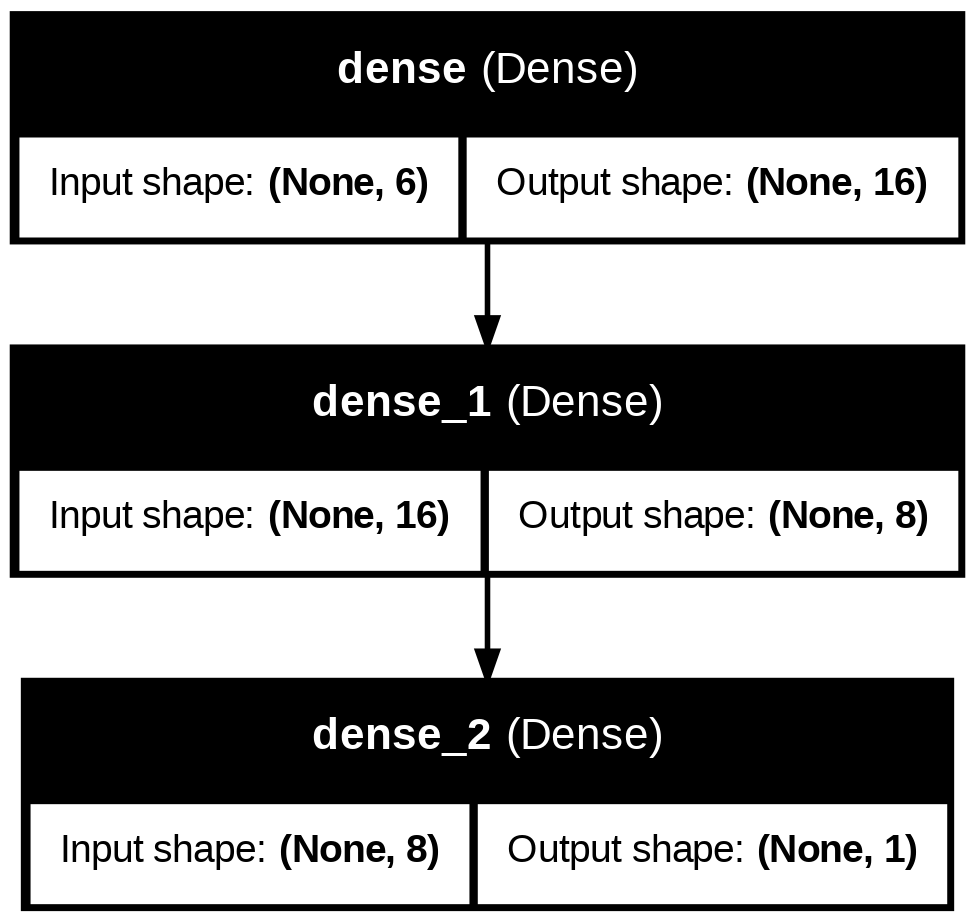

In [31]:
# plot arsitektur model
plot_model(model, show_shapes=True, show_layer_names=True)

In [32]:
# melatih model
history = model.fit(X_train, y_train, epochs=50, batch_size=16, validation_split=0.2, verbose=1)

Epoch 1/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8121 - loss: 0.6322 - val_accuracy: 0.9062 - val_loss: 0.5539
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9382 - loss: 0.5156 - val_accuracy: 0.9750 - val_loss: 0.4287
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9855 - loss: 0.3798 - val_accuracy: 0.9937 - val_loss: 0.2845
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9956 - loss: 0.2374 - val_accuracy: 1.0000 - val_loss: 0.1666
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.1406 - val_accuracy: 1.0000 - val_loss: 0.0977
Epoch 6/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0807 - val_accuracy: 1.0000 - val_loss: 0.0605
Epoch 7/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0527 - val_accuracy: 1.0000 - val_loss: 0.0394
Epoch 8/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0341 - val_accuracy: 1.0000 - val_loss

# Evaluation

In [33]:
y_pred = model.predict(X_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


In [37]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred)
print(f'Akurasi (R-squared): {r2 * 100:.2f}%')

Akurasi (R-squared): 100.00%


# Deployment

## Model Simulation

In [38]:
from tensorflow.keras.layers import Dropout
from tensorflow.keras.regularizers import l2

In [39]:
# membangun model ANN Optimasi
model = Sequential()
model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],), kernel_regularizer=l2(0.01)))
Dropout(0.3)
model.add(Dense(32, activation='relu', kernel_regularizer=l2(0.01)))
Dropout(0.3)
model.add(Dense(16, activation='relu', kernel_regularizer=l2(0.01)))
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [40]:
# COMPILE model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [41]:
# melatih model
from tensorflow.keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.2,
    # callbacks=[early_stopping],
    verbose=1
)

Epoch 1/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.8284 - loss: 1.3123 - val_accuracy: 1.0000 - val_loss: 0.9543
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.8494 - val_accuracy: 1.0000 - val_loss: 0.6065
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.5617 - val_accuracy: 1.0000 - val_loss: 0.4638
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 0.4379 - val_accuracy: 1.0000 - val_loss: 0.3686
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 1.0000 - loss: 0.3492 - val_accuracy: 1.0000 - val_loss: 0.2978
Epoch 6/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.2826 - val_accuracy: 1.0000 - val_loss: 0.2445
Epoch 7/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.2331 - val_accuracy: 1.0000 - val_loss: 0.2042
Epoch 8/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.1957 - val_accuracy: 1.0000 - val_loss

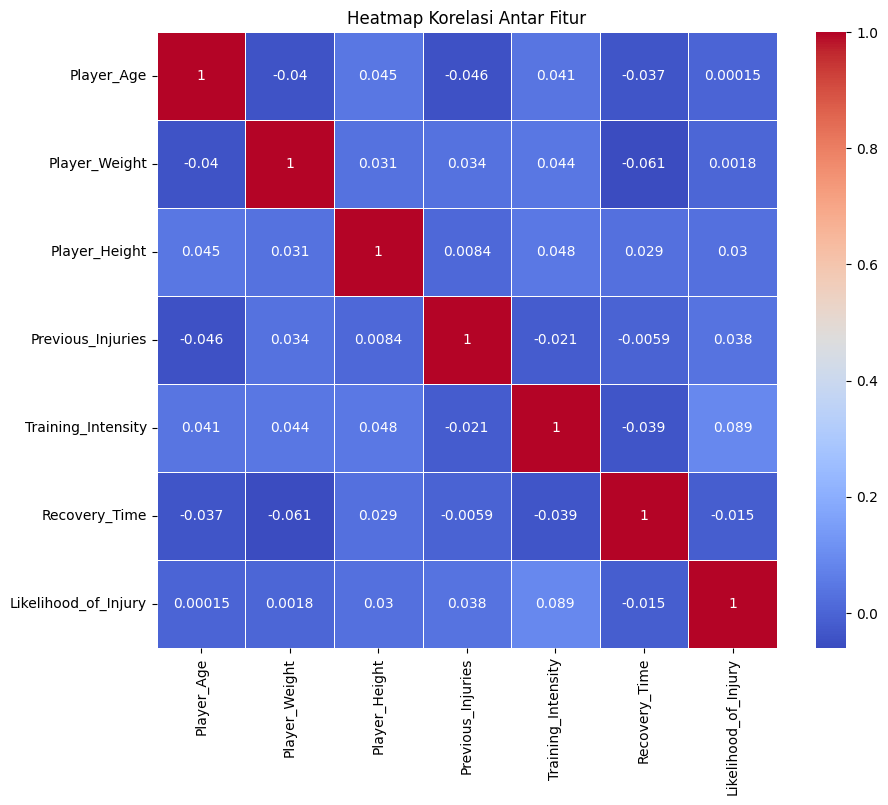

In [42]:
correlation_matrix = data.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Heatmap Korelasi Antar Fitur")
plt.show()

In [43]:
sample_input = np.array([[37,	70.996271,	174.581650,	0,	0.226522,	6]])
sample_input_df = pd.DataFrame(sample_input)

In [44]:
sample_input_scaled = scaler.transform(sample_input_df)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [45]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(data['Likelihood_of_Injury'])

# After model prediction:
predicted_class = np.argmax(model.predict(sample_input_scaled))
predicted_injury = label_encoder.inverse_transform([predicted_class])  # Use the defined label_encoder

print(f"prediction injury: {predicted_injury}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
prediction injury: [0]


## Save Model

In [ ]:
# Konversi model ke TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# Simpan model
with open('predict_injury.tflite', 'wb') as f:
    f.write(tflite_model)

In [ ]:
# Simpan label encoder dan scaler
# Simpan label encoder dan scaler
import joblib
joblib.dump(label_encoder, 'label_encoder.pkl')
joblib.dump(scaler, 'scaler.pkl')